In [1]:
import os
import getdist
from getdist import MCSamples, plots
import numpy as np

# DEFINIR LAS RUTAS
# Para Planck, usamos la RAÍZ (sin .txt) porque son múltiples archivos
ruta_planck = r"C:\Users\hijos\Investigacion 1\Planck\base\plikHM_TTTEEE_lowl_lowE_lensing\base_plikHM_TTTEEE_lowl_lowE_lensing"

# Para Pantheon, usamos EL ARCHIVO EXACTO porque es un único archivo CosmoSIS
archivo_pantheon = r"C:\Users\hijos\Investigacion 1\Pantheon+SH0ES_LambdaCDM.txt"


print("Cargando la cadena de Planck...")
chain_planck = getdist.mcsamples.loadMCSamples(ruta_planck, settings={'ignore_rows': 0.3})

# CARGAR PANTHEON (Modo Manual para CosmoSIS)

print("Cargando la cadena de Pantheon...")
datos_pantheon_crudos = np.loadtxt(archivo_pantheon, comments='#')

# Cortamos el primer 30% como "burn-in" 
burn_in = int(0.3 * len(datos_pantheon_crudos))
datos_pantheon_limpios = datos_pantheon_crudos[burn_in:]

# Según el doc:
# Columna 0 es omega_m
# Columna 1 es H0
# Extraemos solo esas dos columnas y las juntamos

col_omega_m = datos_pantheon_limpios[:, 0]

#Multiplicamos por 100 para convertir 'h' en 'H0'
col_H0 = datos_pantheon_limpios[:, 1] * 100 

# Las juntamos
muestras_pantheon = np.column_stack((col_H0, col_omega_m))


# Creamos el objeto MCSamples manualmente. 
# Le damos los MISMOS nombres que usa Planck ('H0' y 'omegam') para poder compararlos.
chain_pantheon = MCSamples(samples=muestras_pantheon, 
                           names=['H0', 'omegam'], 
                           labels=['H_0', r'\Omega_m'])

print("Datasets cargados exitosamente!")

# Verificación final de parámetros
print("\nParámetros en Planck:", chain_planck.getParamNames().list())
print("Parámetros en Pantheon:", chain_pantheon.getParamNames().list())

Cargando la cadena de Planck...
Cargando la cadena de Pantheon...
Removed no burn in
Datasets cargados exitosamente!

Parámetros en Planck: ['omegabh2', 'omegach2', 'theta', 'tau', 'logA', 'ns', 'calPlanck', 'acib217', 'xi', 'asz143', 'aps100', 'aps143', 'aps143217', 'aps217', 'aksz', 'kgal100', 'kgal143', 'kgal143217', 'kgal217', 'galfTE100', 'galfTE100143', 'galfTE100217', 'galfTE143', 'galfTE143217', 'galfTE217', 'cal0', 'cal2', 'H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'sigma8', 'S8', 's8omegamp5', 's8omegamp25', 's8h5', 'rdragh', 'rmsdeflect', 'zrei', 'A', 'clamp', 'DL40', 'DL220', 'DL810', 'DL1420', 'DL2000', 'ns02', 'yheused', 'YpBBN', 'DHBBN', 'age', 'zstar', 'rstar', 'thetastar', 'DAstar', 'zdrag', 'rdrag', 'kd', 'thetad', 'zeq', 'keq', 'thetaeq', 'thetarseq', 'Hubble015', 'DM015', 'Hubble038', 'DM038', 'Hubble051', 'DM051', 'Hubble061', 'DM061', 'Hubble233', 'DM233', 'fsigma8z015', 'sigma8z015', 'fsigma8z038', 'sigma8z038', 'fsigma8z051', 'sigma8z051', 'fsigma8z061', 

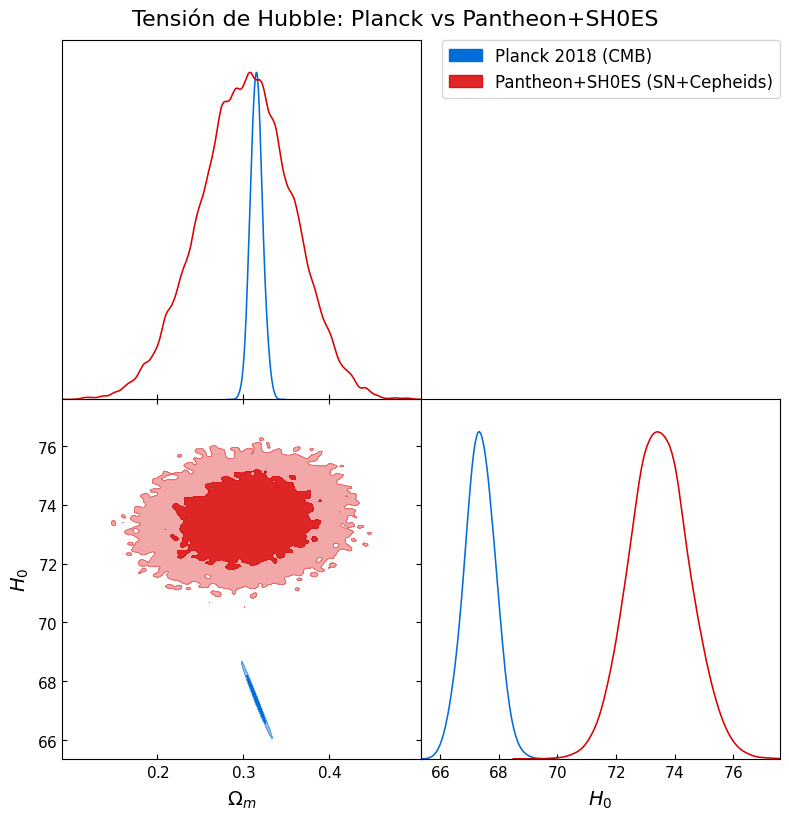

In [12]:
import matplotlib.pyplot as plt

#Queremos comparar H0 y omegam
parametros_a_graficar = ['omegam', 'H0']

#figura
g = plots.get_subplot_plotter(width_inch=8)

# Creamos el gráfico ocupando ambas cadenas
g.triangle_plot([chain_planck, chain_pantheon], 
                parametros_a_graficar, 
                filled=True, 
                legend_labels=['Planck 2018 (CMB)', 'Pantheon+SH0ES (SN+Cepheids)'],
                contour_colors=["#006DD9FF", '#D90000']) # Azul (Planck) y Rojo (Pantheon)

plt.suptitle('Tensión de Hubble: Planck vs Pantheon+SH0ES', fontsize=16, y =1.02)
plt.show()

### Cálculo Analítico de la Tensión (Rule of Thumb)

Asumiendo distribuciones gaussianas. La fórmula mide la diferencia de las medias ponderada por el error combinado:

$$T = \frac{|H_{0, \text{Planck}} - H_{0, \text{Pantheon}}|}{\sqrt{\sigma_{\text{Planck}}^2 + \sigma_{\text{Pantheon}}^2}}$$

Donde $T$ es el nivel de tensión expresado en unidades de desviación estándar ($\sigma$). En cosmología, una tensión mayor a $3\sigma$ se considera "interesante", y mayor a $5\sigma$ se considera un resultado estadísticamente significativo.

In [ ]:
# CÁLCULO DE TENSIÓN 1D (H0) Rule of thumb

# Extraemos las estadísticas 1D marginadas de cada cadena
stats_planck = chain_planck.getMargeStats()
stats_pantheon = chain_pantheon.getMargeStats()

# Sacamos la media y el error para Planck
mean_H0_planck = stats_planck.parWithName('H0').mean
err_H0_planck = stats_planck.parWithName('H0').err

# Lo mismo para Pantheon
mean_H0_pantheon = stats_pantheon.parWithName('H0').mean
err_H0_pantheon = stats_pantheon.parWithName('H0').err

# Aplicamos la fórmula: T = |media1 - media2| / sqrt(err1^2 + err2^2)
diferencia_H0 = abs(mean_H0_planck - mean_H0_pantheon)
error_combinado_H0 = np.sqrt(err_H0_planck**2 + err_H0_pantheon**2)
tension_1d = diferencia_H0 / error_combinado_H0

print(f"H0 Planck:   {mean_H0_planck:.2f} ± {err_H0_planck:.2f}")
print(f"H0 Pantheon: {mean_H0_pantheon:.2f} ± {err_H0_pantheon:.2f}")
print(f"Tensión 1D:  {tension_1d:.2f} sigmas\n")

H0 Planck:   67.36 ± 0.54
H0 Pantheon: 73.48 ± 1.03
Tensión 1D:  5.28 sigmas



Ahora vamos a calcular $Q_{DM}$ ocupando tensiometer, álgebra "a mano" y multimeter

In [4]:
# Q_DM_tensiometer

from tensiometer import gaussian_tension
import scipy.stats as stats

parametros_comunes = ['H0', 'omegam']

# Tensiometer exige por defecto que los límites de las cadenas coincidan.
# Si ya tienes esto en tu código, no necesitas repetirlo.
for param in parametros_comunes:
    limite = chain_planck.ranges.upper.get(param)
    chain_pantheon.ranges.setRange(param, [chain_planck.ranges.lower.get(param), limite])

q_dm_tens, dof_tens = gaussian_tension.Q_DM(chain_planck, chain_pantheon, param_names=parametros_comunes)

#Conversión a sigmas
tension_tens = stats.norm.isf(stats.chi2.sf(q_dm_tens, dof_tens) / 2)

print(f"Q_DM_tensiometer: {q_dm_tens:.3f}")
print(f"Tensión Tensiometer: {tension_tens:.3f} sigmas")

Q_DM_tensiometer: 28.162
Tensión Tensiometer: 4.944 sigmas


In [13]:
#Calcular la tensión con álgebra "a mano"
parametros_comunes = ['H0', 'omegam']

#Sacamos los vectores de medias (theta_A y theta_B) solo para los valores de H0 y omegam
theta_planck = chain_planck.getMeans([chain_planck.index[p] for p in parametros_comunes])
theta_pantheon = chain_pantheon.getMeans([chain_pantheon.index[p] for p in parametros_comunes])

#Matrices de covarianza (C_A y C_B)
cov_planck = chain_planck.cov(parametros_comunes)
cov_pantheon = chain_pantheon.cov(parametros_comunes)

#Aplicar la Ecuación 
delta_theta = theta_planck - theta_pantheon              # (theta_B - theta_A)
suma_covarianzas = cov_planck + cov_pantheon             # (C_A + C_B)
matriz_inversa = np.linalg.inv(suma_covarianzas)         # (C_A + C_B)^(-1)

#Multiplicación matricial: delta_T * Inversa * delta
q_dm_manual = np.dot(delta_theta.T, np.dot(matriz_inversa, delta_theta))
grados_libertad_manual = len(parametros_comunes)

#Convertir a sigmas
p_value_manual = stats.chi2.sf(q_dm_manual, grados_libertad_manual)
tension_manual = stats.norm.isf(p_value_manual / 2)

print(f"Q_DM (álgebra): {q_dm_manual:.3f}")
print(f"Grados de libertad: {grados_libertad_manual}")
print(f"Tensión: {tension_manual:.3f} sigmas")

Q_DM (álgebra): 28.120
Grados de libertad: 2
Tensión: 4.939 sigmas


In [ ]:
# Q_DM utilizando Multimeter
from scipy.linalg import sqrtm, inv
from scipy.stats import chi2
# Importamos utils que está en multimeter.utils.utils
from multimeter.utils import utils 

parametros_comunes = ['H0', 'omegam']

#Extraemos medias y covarianzas
theta_A = chain_planck.getMeans([chain_planck.index[p] for p in parametros_comunes])
theta_B = chain_pantheon.getMeans([chain_pantheon.index[p] for p in parametros_comunes])

cov_A = chain_planck.cov(parametros_comunes)
cov_B = chain_pantheon.cov(parametros_comunes)

#Aplicamos la ecuacio´n exacta que aparece en el repositorio:
# r_1 = sqrtm(inv(cov_A + cov_B)) * (mean_A - mean_B)
inversa_suma_cov = inv(cov_A + cov_B)
raiz_matriz = sqrtm(inversa_suma_cov)
r_1 = np.dot(raiz_matriz, (theta_A - theta_B))

# Q_DM es la norma al cuadrado de este vector
q_dm_multi = np.linalg.norm(r_1)**2

#convertir a sigmas
dof = len(parametros_comunes)
pte = chi2(dof).sf(q_dm_multi)
tension_sigmas = utils.PTE_to_n_sigma(pte)

print(f"Q_DM (Multimeter): {q_dm_multi:.3f}")
print(f"Tensión (Multimeter): {tension_sigmas:.3f} sigmas")

Q_DM (Multimeter): 28.120
Tensión (Multimeter): 4.939 sigmas


*Ahora procederemos con $Q_{UDM}$*

In [7]:
# Definir la ruta a la cadena conjunta (Planck + Pantheon)
ruta_conjunta = r"C:\Users\hijos\Investigacion 1\Planck\base\plikHM_TTTEEE_lowl_lowE_lensing\base_plikHM_TTTEEE_lowl_lowE_lensing_post_Pantheon18"

chain_joint = getdist.mcsamples.loadMCSamples(ruta_conjunta, settings={'ignore_rows': 0.3})

print("Cadena conjunta cargada con éxito")

Cadena conjunta cargada con éxito


In [8]:
# Q_UDM usando Tensiometer
from tensiometer import gaussian_tension
import scipy.stats as stats

parametros_comunes = ['H0', 'omegam']

# Usamos la función de tensiometer que maneja el ruido numérico
q_udm_tens, dof_udm_tens = gaussian_tension.Q_UDM(chain_planck, chain_joint, param_names=parametros_comunes)

# Convertir a sigmas
tension_udm_tens = stats.norm.isf(stats.chi2.sf(q_udm_tens, dof_udm_tens) / 2)

print(f"Q_UDM (Tensiometer): {q_udm_tens:.3f}")
print(f"Grados de libertad: {dof_udm_tens}")
print(f"Tensión (UDM): {tension_udm_tens:.3f} sigmas")

Q_UDM (Tensiometer): 0.321
Grados de libertad: 1
Tensión (UDM): 0.566 sigmas
